
100%|██████████| 2/2 [00:00<?, ?it/s]


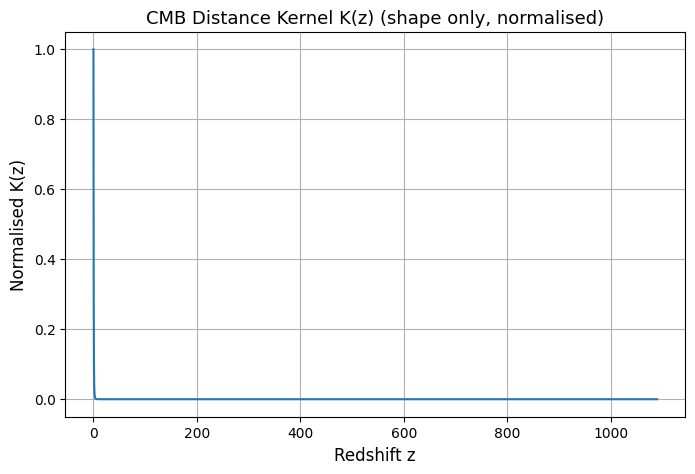


0it [00:00, ?it/s]

In [9]:
# Import libraires 
import numpy as np
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt
from tqdm import tqdm

# Cosmology setup (ΛCDM)
Omega_m = 0.3191
Omega_L = 1.0 - Omega_m
H0 = 67.4 

def H_bg(z):
    # Background Hubble parameter    
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_L) 

def cmb_distance_kernel(z_star, n_points):
   
    # Redshift grid
    z = np.linspace(0.0, z_star, n_points)

    # Integrand f(z) = ΩΛ / H(z)^3
    f = 1 / H_bg(z)**3

    # Cumulative integral F(z) = ∫_0^z f(z') dz'
    F = cumulative_trapezoid(f, z, initial=0.0)

    # Inner integral I(z) = ∫_z^{z_star} f(z') dz' = F(z_star) - F(z)
    I = F[-1] - F

    # Kernel (positive convention)
    prefactor = 3 * Omega_L * H0**2 / 2
    K = prefactor * I / (1 + z)

    return z, K

#Computing and plotting Kernel

z, K = tqdm(cmb_distance_kernel(z_star=1090, n_points=100000))

# Normalise for plotting (shape only)
K_norm = K / np.max(K)

plt.figure(figsize=(8, 5))
plt.plot(z, K_norm)
plt.xlabel("Redshift z", fontsize=12)
plt.ylabel("Normalised K(z)", fontsize=12)
plt.title("CMB Distance Kernel K(z) (shape only, normalised)", fontsize=13)
plt.grid(True)
tqdm(plt.show())


In [11]:
# Crossover calculator
# Define parameterisation - coeffient of w_a
def wa_coeff(z):
    #CPL
    return z / (1 + z)

def I_1(z_star, n_points):
    #redshift grid
    z = np.linspace(0.0, z_star, n_points)

    # Integrand function
    f = K

    # Integrating
    F = cumulative_trapezoid(f, z, initial=0.0)

    #Return integrand to z_star
    I = F[-1]

    return I

def I_2(z_star, n_points):
    #redshift grid
    z = np.linspace(0.0, z_star, n_points)

    # Integrand function
    f = K * wa_coeff(z)

    # Integrating
    F = cumulative_trapezoid(f, z, initial=0.0)

    #Return integrand to z_star
    I = F[-1]

    return I

def z_cross(I_1, I_2, z):
    from scipy.optimize import fsolve

    # Define the equation as a lambda function
    func = lambda z: 1 - (I_1 / I_2) * wa_coeff(z)

    # Provide an initial guess for the solution
    z_initial_guess = 0.5

    # Solve the equation
    z_crossover = fsolve(func, z_initial_guess)
    z_crossover = z_crossover[0]

    # In terms of scale factor
    a_crossover = 1 / (1 + z_crossover)
    return z_crossover, a_crossover, I_1/I_2

z_cross(I_1(1090, 100000), I_2(1090, 100000) , z)



(0.3715253364349258, 0.7291152218881715, 3.691606471837901)

In [5]:
# Import libraires 
import numpy as np
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt
from tqdm import tqdm

# Cosmology setup (ΛCDM)
Omega_m = 0.315
Omega_L = 1.0 - Omega_m
H0 = 67.4 

def H_bg(z):
    # Background Hubble parameter    
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_L) 

def cmb_distance_kernel(z_star, n_points):
   
    # Redshift grid
    z = np.linspace(0.0, z_star, n_points)

    # Integrand f(z) = ΩΛ / H(z)^3
    f = 1 / H_bg(z)**3

    # Cumulative integral F(z) = ∫_0^z f(z') dz'
    F = cumulative_trapezoid(f, z, initial=0.0)

    # Inner integral I(z) = ∫_z^{z_star} f(z') dz' = F(z_star) - F(z)
    I = F[-1] - F

    # Kernel (positive convention)
    prefactor = 3 * Omega_L * H0**2 / 2
    K = prefactor * I / (1 + z)

    return z, K


# Crossover calculator
# Define parameterisation - coeffient of w_a
def wa_coeff(z):
    #CPL
    return z / (1 + z)

def I_1(z_star, n_points):
    #redshift grid
    z = np.linspace(0.0, z_star, n_points)

    # Integrand function
    f = K

    # Integrating
    F = cumulative_trapezoid(f, z, initial=0.0)

    #Return integrand to z_star
    I = F[-1]

    return I

def I_2(z_star, n_points):
    #redshift grid
    z = np.linspace(0.0, z_star, n_points)

    # Integrand function
    f = K * wa_coeff(z)

    # Integrating
    F = cumulative_trapezoid(f, z, initial=0.0)

    #Return integrand to z_star
    I = F[-1]

    return I

def z_cross(I_1, I_2, z):
    from scipy.optimize import fsolve

    # Define the equation as a lambda function
    func = lambda z: 1 - (I_1 / I_2) * wa_coeff(z)

    # Provide an initial guess for the solution
    z_initial_guess = 0.5

    # Solve the equation
    z_crossover = fsolve(func, z_initial_guess)
    z_crossover = z_crossover[0]

    # In terms of scale factor
    a_crossover = 1 / (1 + z_crossover)
    return z_crossover, a_crossover, I_1/I_2

z_cross(I_1(1090, 100000), I_2(1090, 100000) , z)

#mirage line slope

w_0 = np.linspace(-1.5, -0.5, 1000)

# MIRAGE LINE EQUATION IMPORTANT
w_a = -(1 + w_0) * (I_1(1090, 100000)/ I_2(1090, 100000))

# Create dataframe for further plotting
df = pd.DataFrame({
        'w_0' : w_0,
        'w_a' : w_a
    })


NameError: name 'pd' is not defined

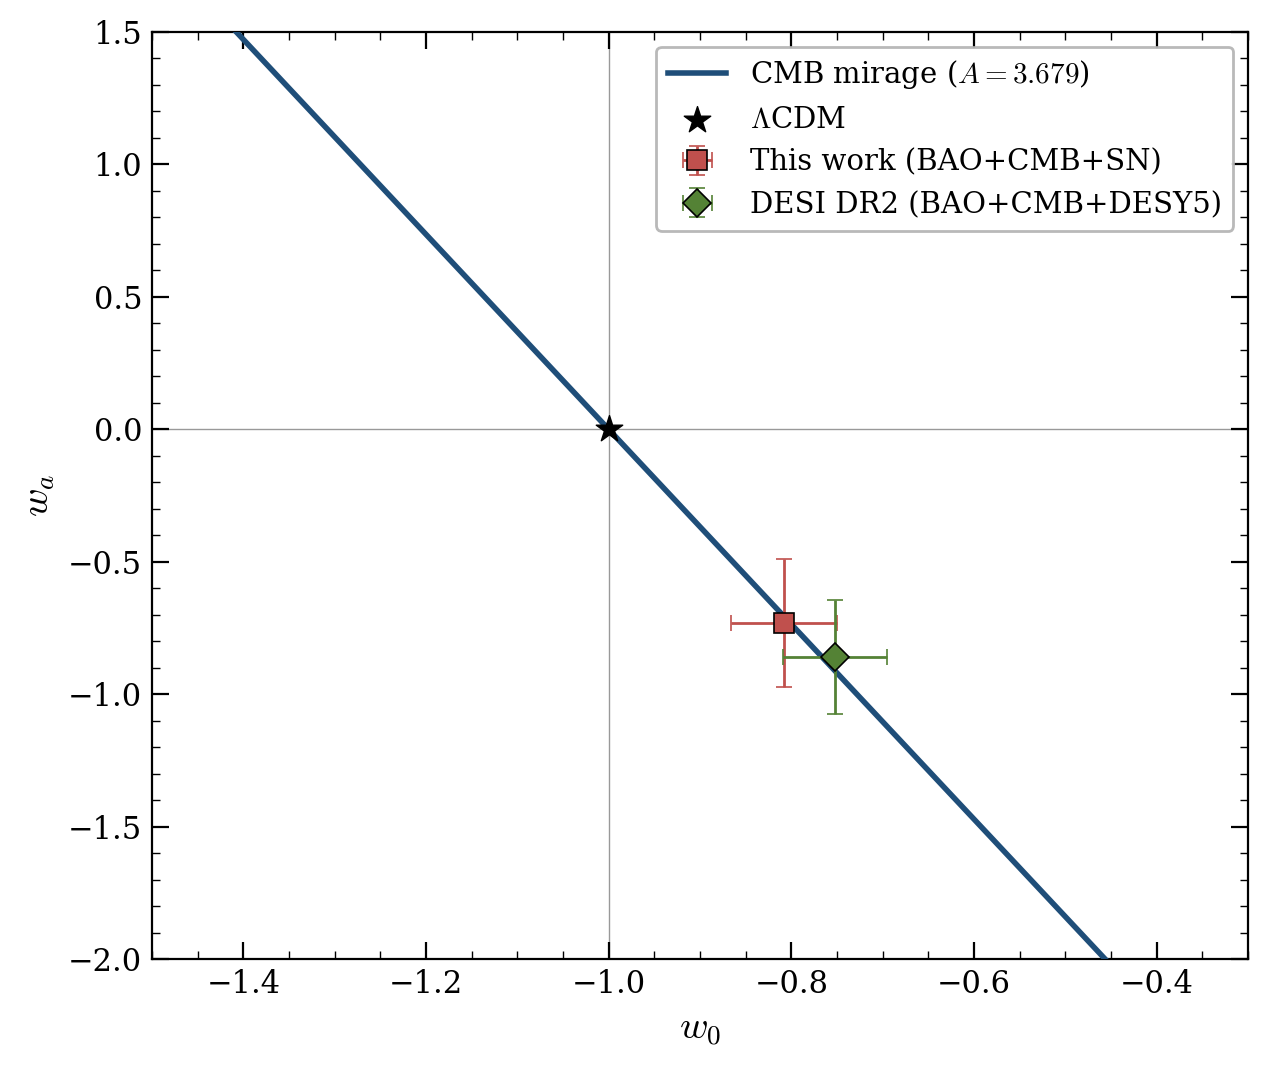

This work:  wa_mirage = -0.706,  actual = -0.731,  Δwa = -0.025
DESI DR2:   wa_mirage = -0.912,  actual = -0.860,  Δwa = +0.052


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10.5,
    'figure.dpi': 200,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
})

# ── Config ─────────────────────────────────────────────────────────
A_CMB = 3.679                            # Mirage slope at Om = 0.3134

# This work: BAO+CMB+SN joint (your Table 2)
W0_TW,  WA_TW  = -0.808, -0.731
SW0_TW, SWA_TW =  0.058,  0.240

# DESI DR2 collaboration: BAO+CMB+DESY5 (their Table V)
# Adjust these if you want a different DESI combination
W0_DESI,  WA_DESI  = -0.752, -0.860
SW0_DESI, SWA_DESI =  0.057,  0.215

# ── Mirage line ────────────────────────────────────────────────────
w0_line = np.linspace(-1.5, -0.3, 300)
wa_mirage = -A_CMB * (1 + w0_line)

# ── Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 5.5))

# Mirage line
ax.plot(w0_line, wa_mirage, color='#1f4e79', lw=2.0,
        label=rf'CMB mirage ($A = {A_CMB:.3f}$)', zorder=3)

# LCDM
ax.scatter([-1], [0], marker='*', s=100, color='k', zorder=5,
           edgecolors='k', linewidths=0.5,
           label=r'$\Lambda$CDM')

# This work
ax.errorbar(W0_TW, WA_TW, xerr=SW0_TW, yerr=SWA_TW,
            fmt='s', color='#c0504d', markersize=7, capsize=3,
            elinewidth=1.0, markeredgecolor='k', markeredgewidth=0.6,
            zorder=5, label='This work (BAO+CMB+SN)')

# DESI DR2
ax.errorbar(W0_DESI, WA_DESI, xerr=SW0_DESI, yerr=SWA_DESI,
            fmt='D', color='#548235', markersize=7, capsize=3,
            elinewidth=1.0, markeredgecolor='k', markeredgewidth=0.6,
            zorder=5, label='DESI DR2 (BAO+CMB+DESY5)')

# Reference lines
ax.axhline(0, color='0.6', lw=0.5, zorder=0)
ax.axvline(-1, color='0.6', lw=0.5, zorder=0)

ax.set_xlabel(r'$w_0$')
ax.set_ylabel(r'$w_a$')
ax.set_xlim(-1.5, -0.3)
ax.set_ylim(-2.0, 1.5)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.legend(loc='upper right', frameon=True, framealpha=0.92, edgecolor='0.7')

fig.tight_layout()
fig.savefig('mirage_line_desi_final.pdf')
fig.savefig('mirage_line_desi_final.png')
plt.show()

# ── Proximity to mirage line ───────────────────────────────────────
wa_mir_tw   = -A_CMB * (1 + W0_TW)
wa_mir_desi = -A_CMB * (1 + W0_DESI)
print(f"This work:  wa_mirage = {wa_mir_tw:+.3f},  actual = {WA_TW:+.3f},  Δwa = {WA_TW - wa_mir_tw:+.3f}")
print(f"DESI DR2:   wa_mirage = {wa_mir_desi:+.3f},  actual = {WA_DESI:+.3f},  Δwa = {WA_DESI - wa_mir_desi:+.3f}")